# 📊 06. LDA 토픽 모델링 — 영어 + 한국어

## 목적
LDA(Latent Dirichlet Allocation)로 리뷰 속 잠재 토픽을 추출한다.
유저들이 주로 어떤 주제에 대해 이야기하는지, 긍정/부정 리뷰에서 토픽 분포가 어떻게 다른지를 파악한다.

## 사전 조건
- `cleaned_reviews_en` 테이블 (44,839건)
- `cleaned_reviews_ko` 테이블 (10,074건)
- `pip install scikit-learn matplotlib`

## 분석 순서
1. 라이브러리 & 데이터 로드
2. BoW(Bag of Words) 벡터화
3. 최적 토픽 수 탐색 (perplexity)
4. LDA 학습 + 토픽별 상위 단어
5. 리뷰별 토픽 할당 + 긍정/부정별 토픽 분포
6. 토픽 레이블링 (수동)
7. 토픽별 원문 확인
8. 시각화
9. 결과 저장

## 이 노트북의 결과물
- 영어 토픽 8개 / 한국어 토픽 6개 (상위 단어 + 레이블)
- 긍정/부정별 토픽 분포 비교
- `topic_assignments_en`, `topic_assignments_ko` 테이블
- `reports/figures/topic_dist_en.png`, `topic_dist_ko.png`

## ⚠️ LDA vs TF-IDF (05편과의 차이)
| | 05편 (TF-IDF + LogReg) | 06편 (LDA) |
|--|----------------------|------------|
| 입력 | TF-IDF 가중치 행렬 | BoW 정수 빈도 행렬 |
| 학습 방식 | 지도 학습 (voted_up 레이블) | **비지도 학습** (레이블 없음) |
| 결과물 | 긍정/부정을 가르는 키워드 | 리뷰 속 **잠재 주제** |
| 해석 | 계수 기반 (자동) | 상위 단어 보고 **수동 레이블링** |

---
## 1. 라이브러리 & 데이터 로드

In [ ]:
import sqlite3
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

DB_PATH = '../data/dave_diver.db'
conn = sqlite3.connect(DB_PATH)

print(' 라이브러리 로드 완료')

 라이브러리 로드 완료


In [5]:
df_en = pd.read_sql("""
    SELECT review_id, voted_up, review_month, play_segment,
           playtime_at_review, review_text, cleaned_text
    FROM cleaned_reviews_en
    WHERE cleaned_text IS NOT NULL AND cleaned_text != ''
""", conn)

df_ko = pd.read_sql("""
    SELECT review_id, voted_up, review_month, play_segment,
           playtime_at_review, review_text, cleaned_text
    FROM cleaned_reviews_ko
    WHERE cleaned_text IS NOT NULL AND cleaned_text != ''
""", conn)

print(f'영어:   {len(df_en):,}건')
print(f'한국어: {len(df_ko):,}건')

영어:   44,839건
한국어: 10,074건


---
## 2. BoW(Bag of Words) 벡터화

LDA는 확률 모델이므로 **정수 빈도 행렬**(CountVectorizer)이 필요하다.
05편의 TF-IDF(실수 가중치)는 LDA에 사용할 수 없다.

| 파라미터 | 값 | 이유 |
|---------|-----|------|
| `max_features` | 3000 | LDA는 피처가 너무 많으면 토픽이 흐려짐 |
| `min_df` | 5 | TF-IDF(3)보다 높게 → 희귀 단어 더 적극 제거 |
| `max_df` | 0.9 | TF-IDF(0.95)보다 낮게 → 흔한 단어 더 적극 제거 |

In [6]:
# ── 영어 BoW ──
count_en = CountVectorizer(max_features=3000, min_df=5, max_df=0.9)
X_bow_en = count_en.fit_transform(df_en['cleaned_text'])

# ── 한국어 BoW ──
count_ko = CountVectorizer(max_features=3000, min_df=5, max_df=0.9)
X_bow_ko = count_ko.fit_transform(df_ko['cleaned_text'])

print(f'영어  BoW: {X_bow_en.shape[0]:,}건 × {X_bow_en.shape[1]:,} 피처')
print(f'한국어 BoW: {X_bow_ko.shape[0]:,}건 × {X_bow_ko.shape[1]:,} 피처')

영어  BoW: 44,839건 × 3,000 피처
한국어 BoW: 10,074건 × 2,186 피처


#### TF-IDF랑 차이점
- Bow는 등장횟수(정수)
    - 빈도가 낮으면 그냥 1,2번 나옴 이렇게 
- TF-IDF는 가중치 점수(소수)
    - 빈도가 낮으면높은점수

---
## 3. 최적 토픽 수 탐색

Perplexity(혼잡도)로 대략적인 범위를 확인한다.
perplexity가 낮을수록 모델이 데이터를 잘 설명하지만,
**너무 낮으면 과적합**이므로 급격히 감소하다가 완만해지는 지점(elbow)을 참고한다.

단, perplexity만으로 최적 토픽 수를 결정하기는 어렵다.
최종적으로는 토픽별 상위 단어를 보고 **해석 가능한 수준**인지를 기준으로 판단한다.

#### Perplexity
- P = (1 / 전체확률) ^ (1/단어수)
- 각 단어가 나올 확률을 모델이 예측
- 예시 : 게임이 재밌다. 에서 모델이 예측한 각 단어 확률
- 게임 -> 0.7 이 토픽에서 자주 나오는 단어
- 재밌다 -> 0.4
- 전체 확률 = 0.28

In [7]:
# ── 영어: 토픽 수 후보 탐색 ──
topic_range = [4, 6, 8, 10, 12]
perplexities_en = []

print('영어 — 토픽 수별 Perplexity')
for n in topic_range:
    lda_temp = LatentDirichletAllocation(
        n_components=n, random_state=42, max_iter=10,
        learning_method='batch', n_jobs=-1
    )
    lda_temp.fit(X_bow_en)
    perp = lda_temp.perplexity(X_bow_en)
    perplexities_en.append(perp)
    print(f'  n_topics={n:2d} → perplexity={perp:.1f}')

print()

# ── 한국어 ──
perplexities_ko = []

print('한국어 — 토픽 수별 Perplexity')
for n in topic_range:
    lda_temp = LatentDirichletAllocation(
        n_components=n, random_state=42, max_iter=10,
        learning_method='batch', n_jobs=-1
    )
    lda_temp.fit(X_bow_ko)
    perp = lda_temp.perplexity(X_bow_ko)
    perplexities_ko.append(perp)
    print(f'  n_topics={n:2d} → perplexity={perp:.1f}')

영어 — 토픽 수별 Perplexity
  n_topics= 4 → perplexity=929.2
  n_topics= 6 → perplexity=927.2
  n_topics= 8 → perplexity=945.8
  n_topics=10 → perplexity=949.0
  n_topics=12 → perplexity=959.8

한국어 — 토픽 수별 Perplexity
  n_topics= 4 → perplexity=931.8
  n_topics= 6 → perplexity=990.5
  n_topics= 8 → perplexity=1052.5
  n_topics=10 → perplexity=1072.7
  n_topics=12 → perplexity=1113.3


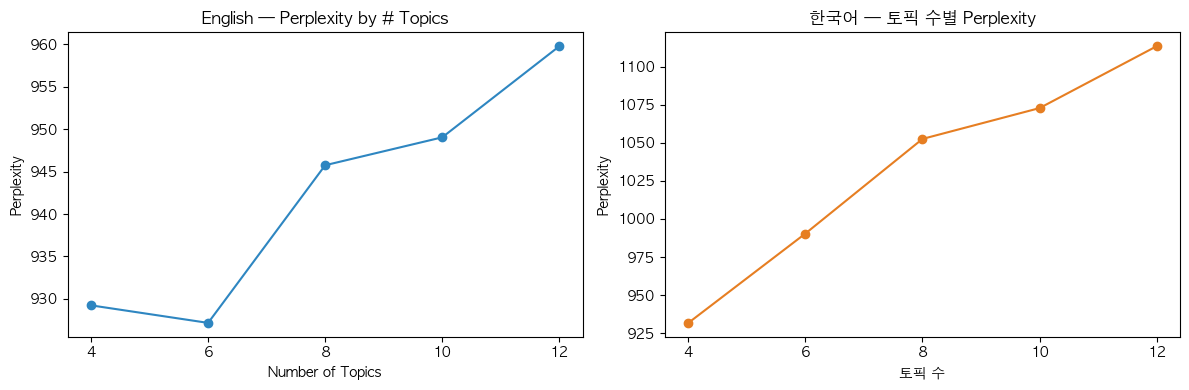

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(topic_range, perplexities_en, 'o-', color='#2E86C1')
axes[0].set_title('English — Perplexity by # Topics')
axes[0].set_xlabel('Number of Topics')
axes[0].set_ylabel('Perplexity')
axes[0].set_xticks(topic_range)

axes[1].plot(topic_range, perplexities_ko, 'o-', color='#E67E22')
axes[1].set_title('한국어 — 토픽 수별 Perplexity')
axes[1].set_xlabel('토픽 수')
axes[1].set_ylabel('Perplexity')
axes[1].set_xticks(topic_range)

plt.tight_layout()
plt.show()

---
## 4. LDA 학습 + 토픽별 상위 단어

Perplexity 결과와 해석 가능성을 기준으로 토픽 수를 결정한다.
- 영어: **8개** (리뷰 44,839건, 다양한 토픽 기대)
- 한국어: **6개** (리뷰 10,074건, 짧은 리뷰 비중 높음)

⚠️ 위 perplexity 결과를 보고 아래 `N_TOPICS_EN`, `N_TOPICS_KO`를 조정할 수 있다.

## 토픽 0,1,2,3 나누는 기준

```
LDA  → "단어들이 함께 등장하는 패턴" 을 확률적으로 찾음
```

### LDA의 가정
```
문서는 여러 토픽의 혼합이다
토픽은 단어들의 확률 분포다

예:
문서 A = 토픽0 70% + 토픽1 20% + 토픽2 10%
토픽0  = "fun=0.3, great=0.2, recommend=0.1 ..."
```

### 학습 과정
```
1. 처음엔 단어를 랜덤하게 토픽에 배정
2. "이 단어가 이 토픽에 있을 확률" 반복 계산
3. 점점 같이 자주 나오는 단어들이 같은 토픽으로 모임
4. 수렴하면 종료
```

실제로:
```
"fun", "great", "recommend" 가 같은 문서에 자주 등장
→ 얘네 같은 토픽으로 묶임
→ 사람이 보니까 "긍정 토픽" 처럼 보이는 것

LDA는 "긍정"이라는 개념을 모름
그냥 같이 나오는 패턴을 찾을 뿐

In [9]:
# ── 토픽 수 설정 (perplexity 결과 보고 조정) ──
N_TOPICS_EN = 6
N_TOPICS_KO = 6

print(f'영어 토픽 수: {N_TOPICS_EN}')
print(f'한국어 토픽 수: {N_TOPICS_KO}')

영어 토픽 수: 6
한국어 토픽 수: 6


In [10]:
# ═══════════════════════════════════════════
#  영어 LDA
# ═══════════════════════════════════════════

lda_en = LatentDirichletAllocation(
    n_components=N_TOPICS_EN,#토픽을 몇개로나눌지
    random_state=42,
    max_iter=20,#학습반복횟수
    learning_method='online',#미니배치로 조금씩학습, batch는 전체데이터로 한번에 학습
    n_jobs=-1
)
lda_en.fit(X_bow_en)

vocab_en = count_en.get_feature_names_out()

print(f'영어 LDA — {N_TOPICS_EN}개 토픽')
print('=' * 60)
for idx, topic in enumerate(lda_en.components_):
    top10 = [vocab_en[i] for i in topic.argsort()[:-11:-1]]
    print(f'\nTopic {idx}: {" · ".join(top10)}')

영어 LDA — 6개 토픽

Topic 0: fun · story · new · mechanic · gameplay · content · buy · loop · awesome · fantastic

Topic 1: amazing · love · year · price · steam · worth · release · enjoyable · buy · indie

Topic 2: love · fun · gameplay · character · art · story · relax · style · music · highly

Topic 3: fishing · diving · restaurant · early · expect · complete · dlc · access · farming · ton

Topic 4: fish · sushi · restaurant · catch · boss · dive · upgrade · fight · day · run

Topic 5: dive · need · casual · life · stardew · chill · easy · long · hard · bug


In [11]:
# ═══════════════════════════════════════════
#  한국어 LDA
# ═══════════════════════════════════════════

lda_ko = LatentDirichletAllocation(
    n_components=N_TOPICS_KO,
    random_state=42,
    max_iter=20,
    learning_method='online',
    n_jobs=-1
)
lda_ko.fit(X_bow_ko)

vocab_ko = count_ko.get_feature_names_out()

print(f'한국어 LDA — {N_TOPICS_KO}개 토픽')
print('=' * 60)
for idx, topic in enumerate(lda_ko.components_):
    top10 = [vocab_ko[i] for i in topic.argsort()[:-11:-1]]
    print(f'\nTopic {idx}: {" · ".join(top10)}')

한국어 LDA — 6개 토픽

Topic 0: 정식 · 재미있 · 출시 · 초밥 · 기대 · 나오 · 버그 · 기다리 · 하루 · 언제

Topic 1: 갓겜 · 모르 · 재미 · 힐링 · 좋아하 · 즐기 · 최고 · 구매 · 재미있 · 스토리

Topic 2: 재밌 · 힐링 · 컨텐츠 · 오랜만 · 나오 · 계속 · 귀엽 · 엔딩 · 민트로켓 · 스토리

Topic 3: 빨리 · 물고기 · 상어 · 얼리 · 아직 · 일단 · 작살 · 지금 · 중독 · 가게

Topic 4: 스토리 · 물고기 · 컨텐츠 · 느낌 · 운영 · 나오 · 요소 · 아쉽 · 재미 · 바다

Topic 5: 넥슨 · 만들 · 꿀잼 · 이렇 · 한국 · 생각 · 도트 · 빠지 · 존재 · 간만에


In [12]:
topic_distributions = lda_ko.transform(X_bow_ko)

def show_topic_reviews(topic_idx, n=5):
    # 해당 토픽에 가장 강하게 속하는 리뷰 인덱스
    top_idx = topic_distributions[:, topic_idx].argsort()[-n:][::-1]
    
    print(f"\n=== Topic {topic_idx} 대표 리뷰 {n}개 ===")
    for rank, idx in enumerate(top_idx):
        score = topic_distributions[idx, topic_idx]
        print(f"\n[{rank+1}위 | 토픽 점수: {score:.3f}]")
        print(df_ko.iloc[idx]['review_text'][:200])  # 200자만
        print("-" * 50)

# 토픽별로 실행
for t in range(6):
    show_topic_reviews(t, n=5)


=== Topic 0 대표 리뷰 5개 ===

[1위 | 토픽 점수: 0.861]
얼른 정식판이 출시나오길 빌며 존버해야징
--------------------------------------------------

[2위 | 토픽 점수: 0.861]
그냥 그렇네요 그런데 정식출시 언제임??? 정식출시 언제임??? 정식출시 언제임??? 정식출시 언제임??? 정식출시 언제임??? 정식출시 언제임??? 정식출시 언제임??? 정식출시 언제임??? 정식출시 언제임??? 정식출시 언제임??? 정식출시 언제임??? 정식출시 언제임??? 정식출시 언제임??? 정식출시 언제임??? 정식출시 언제임??? 정식출시 언제임
--------------------------------------------------

[3위 | 토픽 점수: 0.860]
DLC 그만 내줘도 되니 얼른 신작 만들어주세요!!
--------------------------------------------------

[4위 | 토픽 점수: 0.833]
재미있어요 정식 출시 기다려지네요
--------------------------------------------------

[5위 | 토픽 점수: 0.833]
재미있습니다 정식 출시를 기대중입니다.
--------------------------------------------------

=== Topic 1 대표 리뷰 5개 ===

[1위 | 토픽 점수: 0.907]
처음 1시간 후기.
2D 픽셀 그래픽이라고 재미없는건 아니다
그래픽 야무지고 연출 조작감 다 좋아용

--------------------------------------------------

[2위 | 토픽 점수: 0.907]
도트 그래픽에만 거부감이 없다면 신나게 즐길 수 있는 게임.
근데 2회차는 잘 모르겠다 ㅜㅜ (노가다 성이 은근 있음)
--------------------------------------------------

[3위 | 토픽 점수: 0.907]
그래픽도 

In [13]:
# topic_distributions은 X_bow_ko 기준 → df_ko랑 길이 같음
topic_assignments = topic_distributions.argmax(axis=1)

y_ko = df_ko['voted_up'].values  # 다시 만들기

for t in range(6):
    mask = topic_assignments == t
    pos_rate = y_ko[mask].mean()
    count = mask.sum()
    print(f"Topic {t} | 문서수={count:4d} | 긍정비율={pos_rate:.2%}")

Topic 0 | 문서수=1305 | 긍정비율=98.39%
Topic 1 | 문서수=1983 | 긍정비율=97.68%
Topic 2 | 문서수=1776 | 긍정비율=98.82%
Topic 3 | 문서수= 758 | 긍정비율=96.97%
Topic 4 | 문서수=2777 | 긍정비율=94.02%
Topic 5 | 문서수=1475 | 긍정비율=98.58%


---
## 5. 리뷰별 토픽 할당 + 긍정/부정별 분포

In [14]:
# ── 각 리뷰에 가장 확률 높은 토픽 할당 ──
df_en['dominant_topic'] = lda_en.transform(X_bow_en).argmax(axis=1)
df_ko['dominant_topic'] = lda_ko.transform(X_bow_ko).argmax(axis=1)

print('영어 — 전체 토픽 분포')
print(df_en['dominant_topic'].value_counts().sort_index())
print()
print('한국어 — 전체 토픽 분포')
print(df_ko['dominant_topic'].value_counts().sort_index())

영어 — 전체 토픽 분포
dominant_topic
0     9336
1     7600
2    13041
3     3468
4     8095
5     3299
Name: count, dtype: int64

한국어 — 전체 토픽 분포
dominant_topic
0    1305
1    1983
2    1776
3     758
4    2777
5    1475
Name: count, dtype: int64


In [15]:
def print_topic_distribution(df, lda_model, vocab, lang_name, n_topics):
    """긍정/부정별 토픽 분포 출력"""
    print(f'{lang_name} — 긍정/부정별 토픽 분포')
    print('=' * 65)
    
    for label, name in [(1, '긍정'), (0, '부정')]:
        subset = df[df['voted_up'] == label]
        dist = subset['dominant_topic'].value_counts().sort_index()
        total = len(subset)
        print(f'\n{name} ({total:,}건):')
        for topic_id in range(n_topics):
            count = dist.get(topic_id, 0)
            pct = count / total * 100
            bar = '█' * int(pct / 2)
            top3 = [vocab[i] for i in lda_model.components_[topic_id].argsort()[:-4:-1]]
            print(f'  Topic {topic_id} [{" ".join(top3):30s}] {pct:5.1f}% ({count:,}건) {bar}')

print_topic_distribution(df_en, lda_en, vocab_en, '영어', N_TOPICS_EN)

영어 — 긍정/부정별 토픽 분포

긍정 (43,190건):
  Topic 0 [fun story new                 ]  20.8% (8,998건) ██████████
  Topic 1 [amazing love year             ]  17.2% (7,408건) ████████
  Topic 2 [love fun gameplay             ]  30.0% (12,946건) ██████████████
  Topic 3 [fishing diving restaurant     ]   7.5% (3,259건) ███
  Topic 4 [fish sushi restaurant         ]  17.2% (7,427건) ████████
  Topic 5 [dive need casual              ]   7.3% (3,152건) ███

부정 (1,649건):
  Topic 0 [fun story new                 ]  20.5% (338건) ██████████
  Topic 1 [amazing love year             ]  11.6% (192건) █████
  Topic 2 [love fun gameplay             ]   5.8% (95건) ██
  Topic 3 [fishing diving restaurant     ]  12.7% (209건) ██████
  Topic 4 [fish sushi restaurant         ]  40.5% (668건) ████████████████████
  Topic 5 [dive need casual              ]   8.9% (147건) ████


In [16]:
print_topic_distribution(df_ko, lda_ko, vocab_ko, '한국어', N_TOPICS_KO)

한국어 — 긍정/부정별 토픽 분포

긍정 (9,776건):
  Topic 0 [정식 재미있 출시                     ]  13.1% (1,284건) ██████
  Topic 1 [갓겜 모르 재미                      ]  19.8% (1,937건) █████████
  Topic 2 [재밌 힐링 컨텐츠                     ]  18.0% (1,755건) ████████
  Topic 3 [빨리 물고기 상어                     ]   7.5% (735건) ███
  Topic 4 [스토리 물고기 컨텐츠                   ]  26.7% (2,611건) █████████████
  Topic 5 [넥슨 만들 꿀잼                      ]  14.9% (1,454건) ███████

부정 (298건):
  Topic 0 [정식 재미있 출시                     ]   7.0% (21건) ███
  Topic 1 [갓겜 모르 재미                      ]  15.4% (46건) ███████
  Topic 2 [재밌 힐링 컨텐츠                     ]   7.0% (21건) ███
  Topic 3 [빨리 물고기 상어                     ]   7.7% (23건) ███
  Topic 4 [스토리 물고기 컨텐츠                   ]  55.7% (166건) ███████████████████████████
  Topic 5 [넥슨 만들 꿀잼                      ]   7.0% (21건) ███


---
## 6. 토픽 레이블링 (수동)

In [29]:
topic_labels_ko = {
    0: 'Topic 0 출시 전 기대',#출시전후 평가들
    1: 'Topic 1 재미',# 재미에 대한 평가
    2: 'Topic 2 재미(구체적)',#재미에 대한 평가인데 구체적임
    3: 'Topic 3 게임플레이',#낚시,잠수등에 대한평가
    4: 'Topic 4 게임 전반 경험',#낚시,잠수를 포함한 스토리나 그래픽등 전체적 평가
    5: 'Topic 5 게임사/개발진',
}

topic_labels_en = {
    0: 'Topic 0 게임 전반적인 평가',#게임 전반에 관한 평가 // 긍정 : 게임이 전반적으로 재밌다. 부정 : 게임 후반부가 재미없다
    1: 'Topic 1 출시 직후 평가',#출시 직후 평가 // 긍정 : 재밌다. 부정 : 실망, 호환문제점
    2: 'Topic 2 감성/아트/분위기',#게임 감성,아트에 대한 평가
    3: 'Topic 3 낚시/잠수',#게임 콘텐츠에 대한 평가
    4: 'Topic 4 게임플레이 루프',#게임 플레이 루프에 대한 평가
    5: 'Topic 5 타 게임사와 비교',# 게임사, 장르에 대한 평가
}

---
## 7. 토픽별 원문 확인

LDA가 추출한 토픽이 실제로 어떤 내용인지, 부정 리뷰 원문으로 검증한다.
이 결과를 보고 위 6번의 레이블을 수정한다.

In [26]:
def show_topic_samples(df, lda_model, vocab, n_topics, n_samples=3, only_negative=False):
    """토픽별 리뷰 원문 샘플 출력"""
    if only_negative:
        df_sub = df[df['voted_up'] == 0]
        label = '부정 리뷰'
    else:
        df_sub = df
        label = '전체 리뷰'
    
    for topic_id in range(n_topics):
        subset = df_sub[df_sub['dominant_topic'] == topic_id]
        if len(subset) == 0:
            continue
        
        top5 = [vocab[i] for i in lda_model.components_[topic_id].argsort()[:-6:-1]]
        print(f'\n--- Topic {topic_id} ({" · ".join(top5)}) — {label} {len(subset)}건 ---')
        
        for _, row in subset.head(n_samples).iterrows():
            text = row['review_text'].replace('\n', ' ')[:200]
            print(f'  • {text}')

print('영어 부정 리뷰 — 토픽별 원문 샘플')
print('=' * 70)
show_topic_samples(df_en, lda_en, vocab_en, N_TOPICS_EN, only_negative=False)

영어 부정 리뷰 — 토픽별 원문 샘플

--- Topic 0 (fun · story · new · mechanic · gameplay) — 전체 리뷰 9336건 ---
  • its fun
  • Great unique content, fun interactive play style, would recommend, affordable
  • This game is a lot of fun, worth a play.

--- Topic 1 (amazing · love · year · price · steam) — 전체 리뷰 7600건 ---
  • Sweet! Chum!
  • the best game ever definetly worth to buy
  • amazing

--- Topic 2 (love · fun · gameplay · character · art) — 전체 리뷰 13041건 ---
  • Peak game 
  • Game is 2 frickin peak 😭
  • To be clear, I absolutely adore this game, as is evident given the hours I've sunk into it.  Unfortunately I am now locked out from being able to play.  I have an old computer that I spent a stupid am

--- Topic 3 (fishing · diving · restaurant · early · expect) — 전체 리뷰 3468건 ---
  • Good game but the bosses are near impossible to fight unless you nail the exact strategy.
  • A lot more depth to the game that I expected. Always tons of fish, recipes and things to explore.
  • This is a pretty a

In [28]:
print('한국어 부정 리뷰 — 토픽별 원문 샘플')
print('=' * 70)
show_topic_samples(df_ko, lda_ko, vocab_ko, N_TOPICS_KO, only_negative=True)

한국어 부정 리뷰 — 토픽별 원문 샘플

--- Topic 0 (정식 · 재미있 · 출시 · 초밥 · 기대) — 부정 리뷰 21건 ---
  • 넥슨냄새가너무남 으
  • 보고 온다면서 바로 보스전 처 시작하고 자빠졌네
  • 열수 분출구 마지막 문 열때 튕기면 세이브까지 날라가는 버그 있음

--- Topic 1 (갓겜 · 모르 · 재미 · 힐링 · 좋아하) — 부정 리뷰 46건 ---
 딱 2시간 긴가민엇는지 모르겠을정도로 불쾌한 아트만 가득함 딱히 퀄이 높다는 느낌도 못받았음분나쁨)로인게임
  • 나는 왜 재미가 없을까 
 하다보니 일하는 기분이 들어서 관둠..

--- Topic 2 (재밌 · 힐링 · 컨텐츠 · 오랜만 · 나오) — 부정 리뷰 21건 ---
  • 게임성 자체는 나쁘지 않았는데 주인공이 스쿠버 장비 착용하고 작살이랑 총으로 불법 어획 하면서 해적들한텐 훈수 두는 게 좀 어이없고 불편했어요. 본인은 물고기들과 상어를 학살하고 다니며 해양 생태계를 파괴한다는 생각이 들어서 삭제했습니다. 고증 오류와 주인공의 위선적인 면모만 없다면 게임 자체는 재밌게 했습니다.
  • 메이플 즐겨하시는 분들은 재밌게 하실 듯
  • 크로노사우루스 너프 해라. 이거 머 2시간 동안 잡는 유투버도 있더만. 재미없음

--- Topic 3 (빨리 · 물고기 · 상어 · 얼리 · 아직) — 부정 리뷰 23건 ---
  • 자꾸 동기화하면 제가 키운 것들이 다 사라져요.. 즈금 두번째 사라졌어요ㅜㅜㅜ 계속 해서 깨고 싶은데 왜 자꾸 없어지나요 참치 개많이 잡아놨는데 미친거 아닌가요 저장하고 나가도 클라우드 동기화 눌렀더니 없어졌어요
  • 시발 너무 튕겨요  가이드 들어가서 무결성검사ㅐ보라고해서햇는데 이제 게임이안켜짐 ㅋ
  • 매력도 없고, 재미도 없는 어인족 ㄹㅇ 개노잼 삭제좀, 물고기 잡고 가게 운영하기 바쁘고 그거 위주로 스토리 돌리지 왜 굳이 없어도 상관없는 어인을 넣어놓은지 모르겠네 선물받은 사람도, 이겜 추천해준 사람도 하나같이 어인 노잼이라고 한다.


In [20]:
# 긍정 리뷰도 확인하고 싶으면 이 셀 실행
print('영어 긍정 리뷰 — 토픽별 원문 샘플')
print('=' * 70)
show_topic_samples(df_en, lda_en, vocab_en, N_TOPICS_EN, n_samples=2, only_negative=False)

영어 긍정 리뷰 — 토픽별 원문 샘플

--- Topic 0 (fun · story · new · mechanic · gameplay) — 전체 리뷰 9336건 ---
  • its fun
  • Great unique content, fun interactive play style, would recommend, affordable

--- Topic 1 (amazing · love · year · price · steam) — 전체 리뷰 7600건 ---
  • Sweet! Chum!
  • the best game ever definetly worth to buy

--- Topic 2 (love · fun · gameplay · character · art) — 전체 리뷰 13041건 ---
  • Peak game 
  • Game is 2 frickin peak 😭

--- Topic 3 (fishing · diving · restaurant · early · expect) — 전체 리뷰 3468건 ---
  • Good game but the bosses are near impossible to fight unless you nail the exact strategy.
  • A lot more depth to the game that I expected. Always tons of fish, recipes and things to explore.

--- Topic 4 (fish · sushi · restaurant · catch · boss) — 전체 리뷰 8095건 ---
  • I liked, but there is a lot to do , I mean a lot. I guess going left, roght up and down all the time is not for me, i rather play something in 3d
  • I just finished playing Dave the Diver, and I genuinely 

---
## 8. 시각화

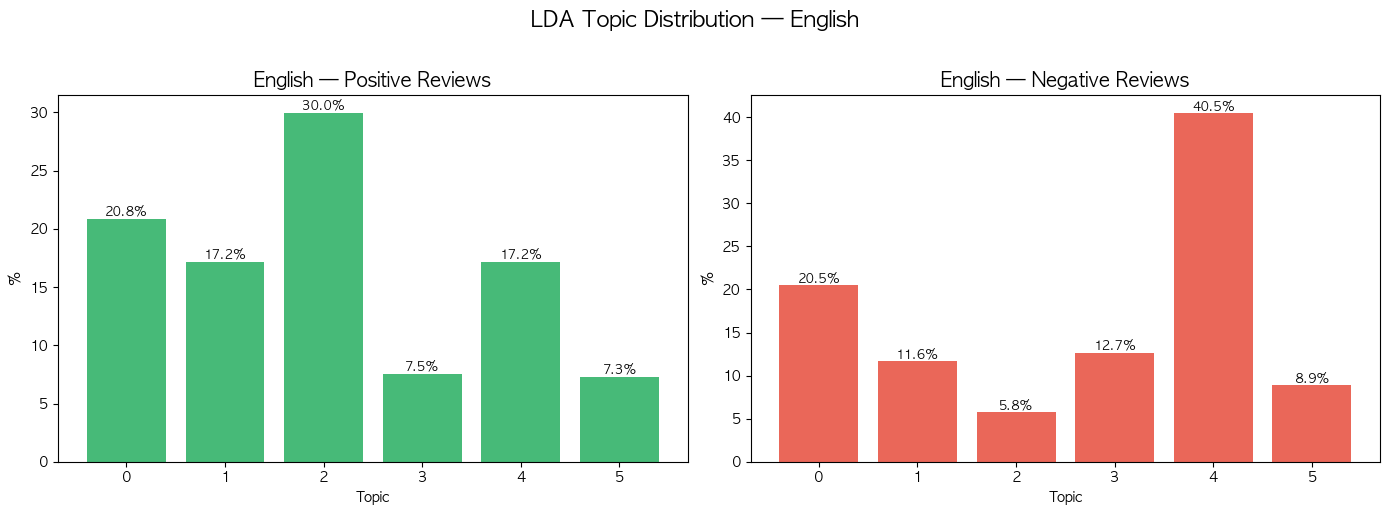

 저장: reports/figures/topic_dist_en.png


In [31]:
# ── 영어: 긍정 vs 부정 토픽 분포 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, name, color) in zip(
    axes, [(1, 'Positive', '#27AE60'), (0, 'Negative', '#E74C3C')]
):
    subset = df_en[df_en['voted_up'] == label]
    dist = subset['dominant_topic'].value_counts().sort_index()
    dist_pct = dist / len(subset) * 100
    
    bars = ax.bar(range(N_TOPICS_EN), [dist_pct.get(i, 0) for i in range(N_TOPICS_EN)],
                  color=color, alpha=0.85)
    ax.set_title(f'English — {name} Reviews', fontsize=14, fontweight='bold')
    ax.set_xlabel('Topic')
    ax.set_ylabel('%')
    ax.set_xticks(range(N_TOPICS_EN))
    
    # 각 바에 비율 표시
    for bar_obj in bars:
        h = bar_obj.get_height()
        if h > 1:
            ax.text(bar_obj.get_x() + bar_obj.get_width()/2, h + 0.3,
                    f'{h:.1f}%', ha='center', fontsize=9)

plt.suptitle('LDA Topic Distribution — English', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/topic_dist_en.png', dpi=150, bbox_inches='tight')
plt.show()
print(' 저장: reports/figures/topic_dist_en.png')

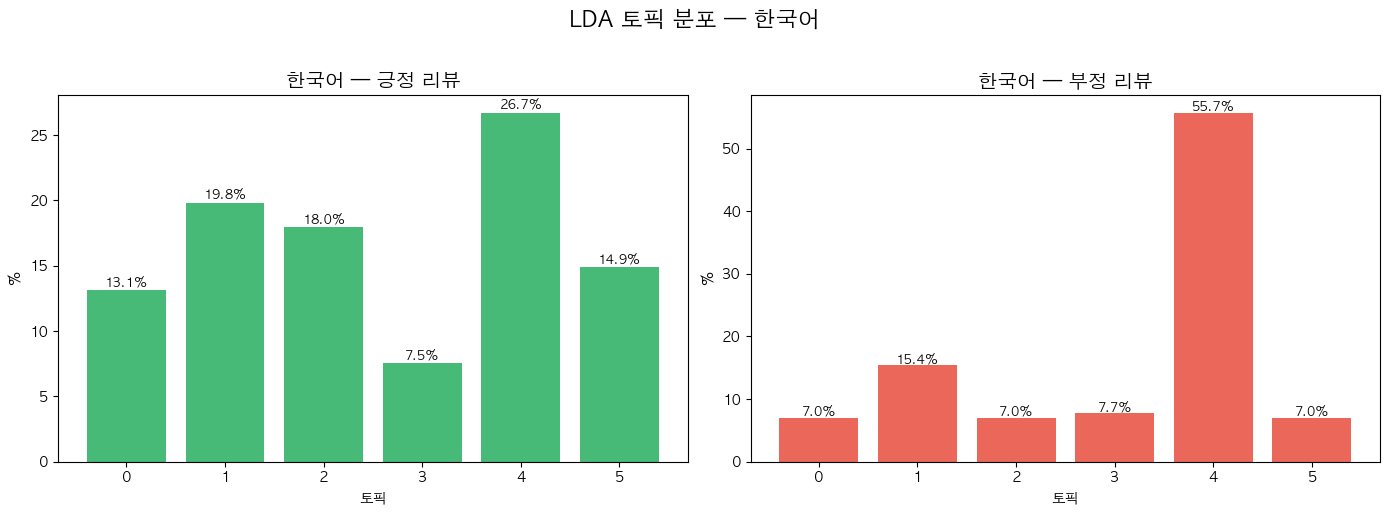

저장: reports/figures/topic_dist_ko.png


In [32]:
# ── 한국어: 긍정 vs 부정 토픽 분포 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, name, color) in zip(
    axes, [(1, '긍정', '#27AE60'), (0, '부정', '#E74C3C')]
):
    subset = df_ko[df_ko['voted_up'] == label]
    dist = subset['dominant_topic'].value_counts().sort_index()
    dist_pct = dist / len(subset) * 100
    
    bars = ax.bar(range(N_TOPICS_KO), [dist_pct.get(i, 0) for i in range(N_TOPICS_KO)],
                  color=color, alpha=0.85)
    ax.set_title(f'한국어 — {name} 리뷰', fontsize=14, fontweight='bold')
    ax.set_xlabel('토픽')
    ax.set_ylabel('%')
    ax.set_xticks(range(N_TOPICS_KO))
    
    for bar_obj in bars:
        h = bar_obj.get_height()
        if h > 1:
            ax.text(bar_obj.get_x() + bar_obj.get_width()/2, h + 0.3,
                    f'{h:.1f}%', ha='center', fontsize=9)

plt.suptitle('LDA 토픽 분포 — 한국어', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/topic_dist_ko.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: reports/figures/topic_dist_ko.png')

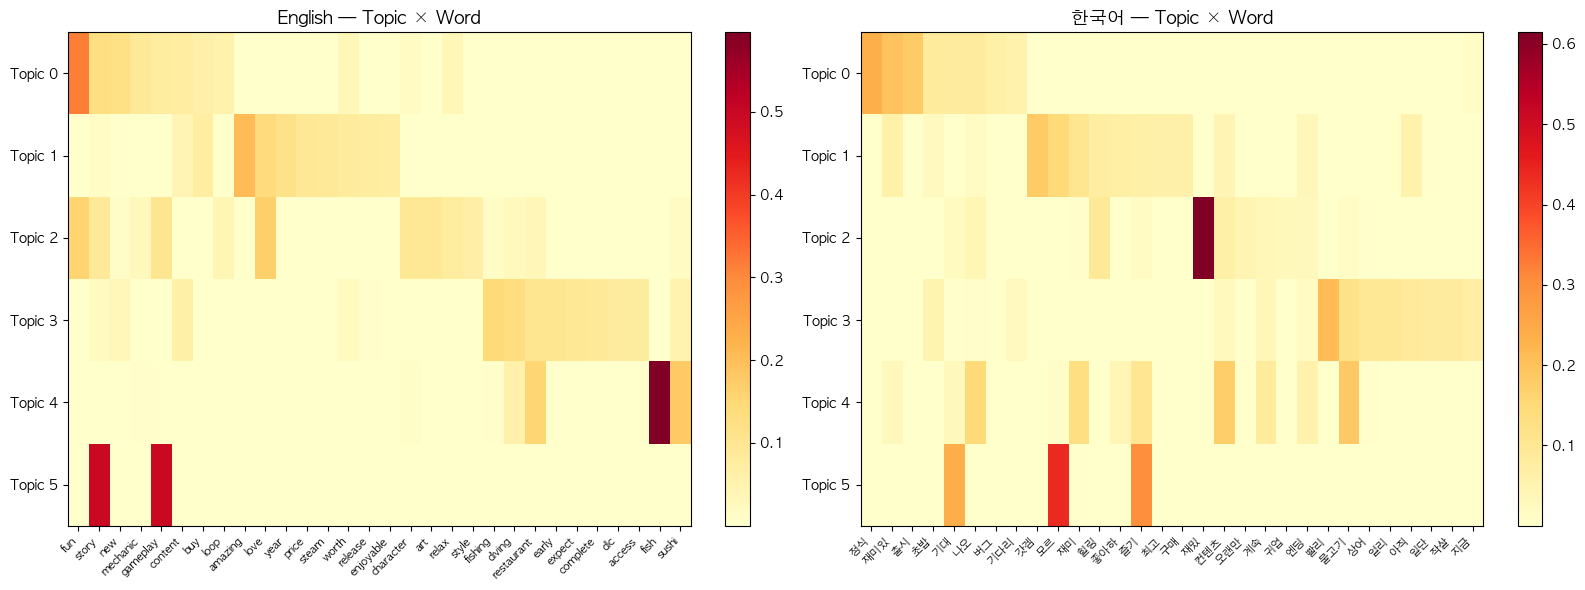

저장: reports/figures/topic_heatmap.png


In [33]:
# ── 영어: 토픽 × 단어 히트맵 (상위 5단어) ──
n_words = 8

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (lda_model, vocab, n_topics, title) in zip(
    axes,
    [(lda_en, vocab_en, N_TOPICS_EN, 'English'),
     (lda_ko, vocab_ko, N_TOPICS_KO, '한국어')]
):
    # 각 토픽의 상위 단어 수집 (중복 제거)
    all_words = []
    for topic in lda_model.components_:
        for i in topic.argsort()[:-n_words-1:-1]:
            if vocab[i] not in all_words:
                all_words.append(vocab[i])
    all_words = all_words[:30]  # 최대 30개
    
    # 히트맵 데이터
    word_indices = [list(vocab).index(w) for w in all_words]
    heatmap_data = lda_model.components_[:, word_indices]
    # 정규화 (토픽별 합 = 1)
    heatmap_data = heatmap_data / heatmap_data.sum(axis=1, keepdims=True)
    
    im = ax.imshow(heatmap_data, aspect='auto', cmap='YlOrRd')
    ax.set_yticks(range(n_topics))
    ax.set_yticklabels([f'Topic {i}' for i in range(n_topics)])
    ax.set_xticks(range(len(all_words)))
    ax.set_xticklabels(all_words, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{title} — Topic × Word', fontsize=13, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig('../reports/figures/topic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: reports/figures/topic_heatmap.png')

---
## 9. 결과 저장

In [36]:
# ── 토픽 할당 결과 저장 ──

# 영어
topic_en_df = df_en[['review_id', 'dominant_topic']].copy()
topic_en_df.columns = ['review_id', 'topic_id']
topic_en_df['topic_label'] = topic_en_df['topic_id'].map(topic_labels_en)
topic_en_df.to_sql('topic_assignments_en', conn, if_exists='replace', index=False)

# 한국어
topic_ko_df = df_ko[['review_id', 'dominant_topic']].copy()
topic_ko_df.columns = ['review_id', 'topic_id']
topic_ko_df['topic_label'] = topic_ko_df['topic_id'].map(topic_labels_ko)
topic_ko_df.to_sql('topic_assignments_ko', conn, if_exists='replace', index=False)

# ── 토픽 상위 단어 저장 ──
topic_words_rows = []
for idx, topic in enumerate(lda_en.components_):
    top10 = [vocab_en[i] for i in topic.argsort()[:-11:-1]]
    topic_words_rows.append({
        'language': 'english', 'topic_id': idx,
        'label': topic_labels_en[idx], 'top_words': ' · '.join(top10)
    })
for idx, topic in enumerate(lda_ko.components_):
    top10 = [vocab_ko[i] for i in topic.argsort()[:-11:-1]]
    topic_words_rows.append({
        'language': 'korean', 'topic_id': idx,
        'label': topic_labels_ko[idx], 'top_words': ' · '.join(top10)
    })

pd.DataFrame(topic_words_rows).to_sql('topic_definitions', conn, if_exists='replace', index=False)

print(' DB 저장 완료')
print(f'  - topic_assignments_en: {len(topic_en_df):,}건')
print(f'  - topic_assignments_ko: {len(topic_ko_df):,}건')
print(f'  - topic_definitions: {len(topic_words_rows)}건')

 DB 저장 완료
  - topic_assignments_en: 44,839건
  - topic_assignments_ko: 10,074건
  - topic_definitions: 12건


---
## 10. DB 연결 종료

In [37]:
conn.close()
print('DB 연결 종료')

DB 연결 종료
